In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git clone https://github.com/falkodz/TER.git /content/TER
!pip install gensim pyLDAvis -q

import os, shutil
os.makedirs('/content/TER/data', exist_ok=True)
shutil.copy('/content/drive/MyDrive/Colab Notebooks/ChatGPT_final.csv',
            '/content/TER/data/ChatGPT_final.csv')
print("Done ✓")

Mounted at /content/drive
Cloning into '/content/TER'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 69 (delta 32), reused 52 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 4.25 MiB | 18.19 MiB/s, done.
Resolving deltas: 100% (32/32), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 63.1 MB/s eta 0:00:00
Done ✓


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/TER/data/ChatGPT_final.csv',
                 usecols=['cleaned_tweet', 'sentiment', 'Date'],
                 low_memory=False)

df['Date'] = pd.to_datetime(df['Date'], utc=True, errors='coerce')
df = df.dropna(subset=['cleaned_tweet', 'Date'])
df = df[df['cleaned_tweet'].str.strip() != '']
df['month'] = df['Date'].dt.to_period('M')

print(f"Shape: {df.shape}")
print(df['month'].value_counts().sort_index())

Shape: (476164, 4)
month
2022-11        77
2022-12     80872
2023-01    105555
2023-02    128459
2023-03    132763
2023-04     28438
Freq: M, Name: count, dtype: int64


/tmp/ipykernel_2873/541831721.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['Date'].dt.to_period('M')


In [ ]:
from gensim import corpora, models
from gensim.models import LdaModel
import warnings
warnings.filterwarnings('ignore')

# Utiliser un échantillon pour accélérer
df_sample = df[df['month'].astype(str).isin(['2022-12', '2023-01', '2023-02', '2023-03'])].sample(50000, random_state=42)

# Tokeniser le texte nettoyé
texts = [tweet.split() for tweet in df_sample['cleaned_tweet'].tolist()]

# Filtrer les tokens trop courts
texts = [[word for word in doc if len(word) > 2] for doc in texts]

# Créer le dictionnaire et le corpus
dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=10, no_above=0.4)
corpus = [dictionary.doc2bow(text) for text in texts]

print(f"Vocabulary size: {len(dictionary)}")
print(f"Corpus size: {len(corpus)}")

Vocabulary size: 5051
Corpus size: 50000


In [ ]:
# Entraînement LDA
print("Training LDA model...")
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=6,
    random_state=42,
    passes=10,
    alpha='auto',
    eta='auto'
)
print("Done ✓")

# Afficher les topics
print("\n=== Topics ===")
for i, topic in lda_model.print_topics(num_words=8):
    print(f"\nTopic {i+1}: {topic}")

Training LDA model...
Done ✓

=== Topics ===

Topic 1: 0.053*"google" + 0.031*"microsoft" + 0.025*"search" + 0.023*"chatbot" + 0.021*"bing" + 0.021*"bard" + 0.021*"day" + 0.016*"midjourney"

Topic 2: 0.036*"artificialintelligence" + 0.029*"technology" + 0.020*"future" + 0.018*"world" + 0.016*"business" + 0.015*"power" + 0.015*"read" + 0.014*"intelligence"

Topic 3: 0.019*"write" + 0.019*"like" + 0.017*"ask" + 0.016*"use" + 0.015*"new" + 0.011*"tool" + 0.011*"good" + 0.010*"think"

Topic 4: 0.040*"tech" + 0.020*"free" + 0.017*"python" + 0.016*"company" + 0.013*"robot" + 0.012*"developer" + 0.012*"programming" + 0.012*"metaverse"

Topic 5: 0.021*"user" + 0.017*"app" + 0.015*"service" + 0.013*"access" + 0.013*"version" + 0.012*"problem" + 0.012*"fast" + 0.011*"soon"

Topic 6: 0.033*"crypto" + 0.018*"invest" + 0.015*"bitcoin" + 0.013*"airdrop" + 0.012*"investment" + 0.012*"btc" + 0.010*"bias" + 0.009*"trading"


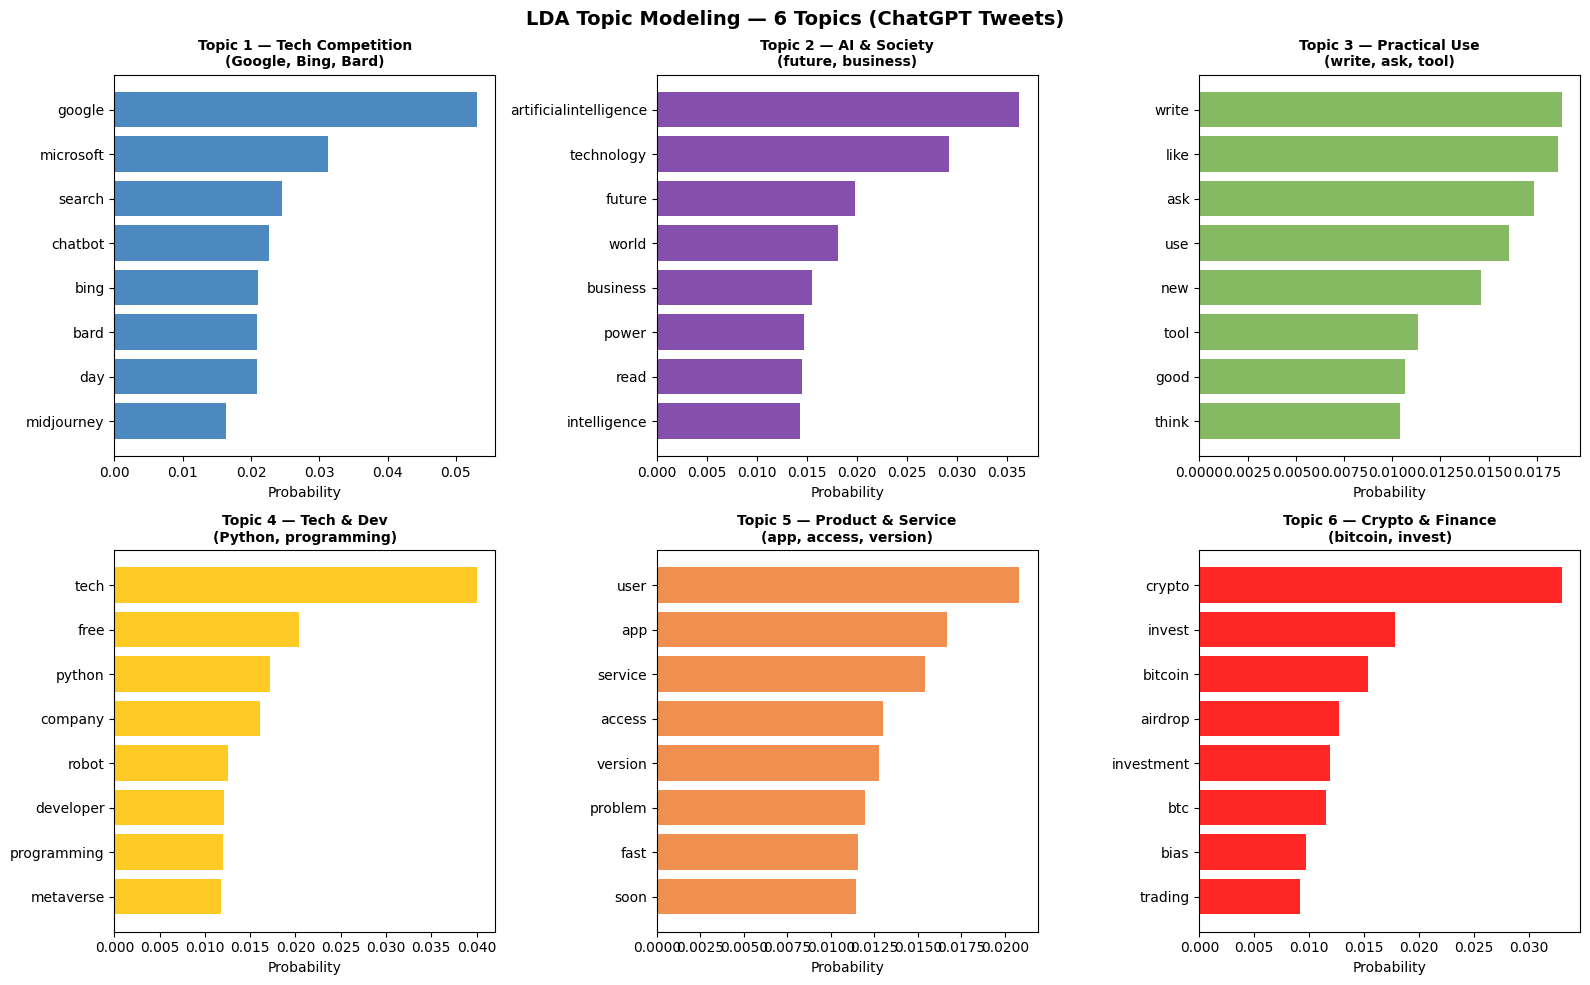

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Labels des topics
topic_labels = [
    "Topic 1\nTech Competition\n(Google, Bing, Bard)",
    "Topic 2\nAI & Society\n(future, business)",
    "Topic 3\nPractical Use\n(write, ask, tool)",
    "Topic 4\nTech & Dev\n(Python, programming)",
    "Topic 5\nProduct & Service\n(app, access, version)",
    "Topic 6\nCrypto & Finance\n(bitcoin, invest)"
]

colors = ['#2E75B6', '#7030A0', '#70AD47', '#FFC000', '#ED7D31', '#FF0000']

# Distribution des topics par document
topic_dist = []
for doc_bow in corpus[:5000]:
    topics = lda_model.get_document_topics(doc_bow, minimum_probability=0)
    topic_dist.append([t[1] for t in sorted(topics, key=lambda x: x[0])])

topic_dist = np.array(topic_dist)
avg_dist = topic_dist.mean(axis=0)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

topic_labels_short = [
    "Tech Competition\n(Google, Bing, Bard)",
    "AI & Society\n(future, business)",
    "Practical Use\n(write, ask, tool)",
    "Tech & Dev\n(Python, programming)",
    "Product & Service\n(app, access, version)",
    "Crypto & Finance\n(bitcoin, invest)"
]

for i in range(6):
    words, probs = zip(*lda_model.show_topic(i, topn=8))
    axes[i].barh(list(words)[::-1], list(probs)[::-1], color=colors[i], alpha=0.85)
    axes[i].set_title(f"Topic {i+1} — {topic_labels_short[i]}", fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Probability')

plt.suptitle('LDA Topic Modeling — 6 Topics (ChatGPT Tweets)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/TER/figures/12_lda_topics.png', dpi=150)
plt.show()

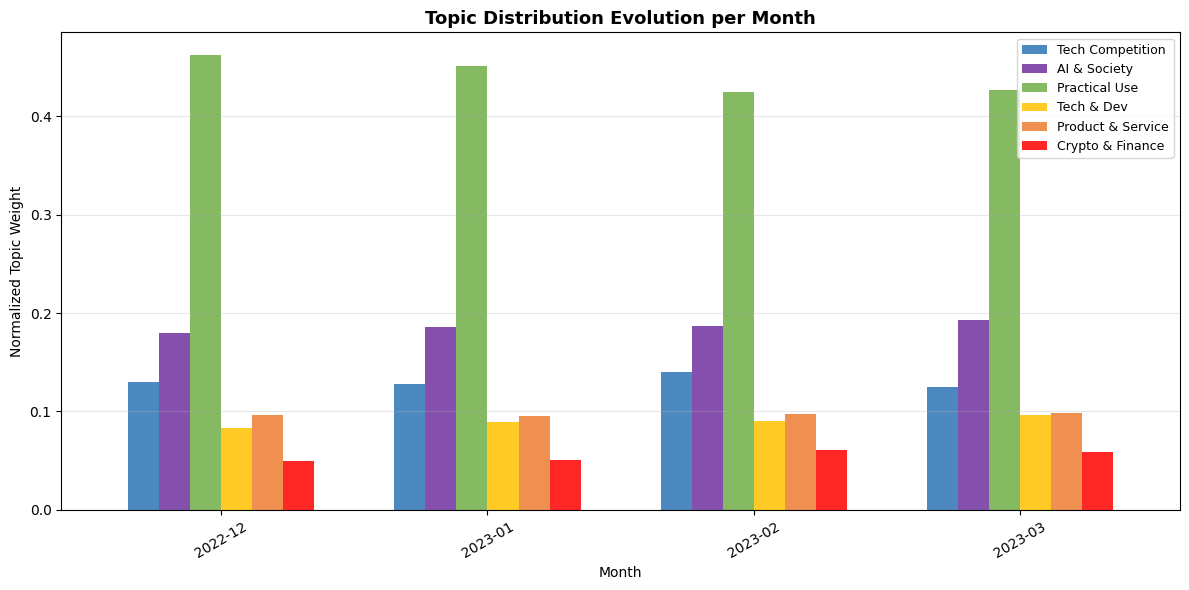

In [ ]:
# Distribution des topics par mois
df_sample['month_str'] = df_sample['month'].astype(str)
months = ['2022-12', '2023-01', '2023-02', '2023-03']

monthly_topics = {m: np.zeros(6) for m in months}

for idx, row in df_sample[df_sample['month_str'].isin(months)].iterrows():
    doc_bow = dictionary.doc2bow(row['cleaned_tweet'].split())
    topics = lda_model.get_document_topics(doc_bow, minimum_probability=0)
    for t_id, t_prob in topics:
        monthly_topics[row['month_str']][t_id] += t_prob

# Normaliser
for m in months:
    total = monthly_topics[m].sum()
    if total > 0:
        monthly_topics[m] /= total

# Visualisation
topic_names = ['Tech Competition', 'AI & Society', 'Practical Use',
               'Tech & Dev', 'Product & Service', 'Crypto & Finance']

monthly_df = pd.DataFrame(monthly_topics, index=topic_names).T

fig, ax = plt.subplots(figsize=(12, 6))
monthly_df.plot(kind='bar', ax=ax, color=colors, alpha=0.85, width=0.7)
ax.set_title('Topic Distribution Evolution per Month', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Normalized Topic Weight')
ax.set_xticklabels(months, rotation=30)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/TER/figures/13_lda_topic_evolution.png', dpi=150)
plt.show()

In [4]:
import subprocess
from getpass import getpass

# Sauvegarder le notebook sur Drive d'abord
# Fichier → Enregistrer une copie dans Drive

import shutil, os
os.makedirs('/content/TER/notebooks', exist_ok=True)
shutil.copy('/content/drive/MyDrive/Colab Notebooks/08_lda_topic_modeling.ipynb',
            '/content/TER/notebooks/08_lda_topic_modeling.ipynb')

subprocess.run(['git', 'config', 'user.email', 'ton@email.com'], cwd='/content/TER')
subprocess.run(['git', 'config', 'user.name', 'falkodz'], cwd='/content/TER')
subprocess.run(['git', 'add', '.'], cwd='/content/TER')
r = subprocess.run(['git', 'commit', '-m', 'Add LDA topic modeling notebook + figures'],
                   cwd='/content/TER', capture_output=True, text=True)
print(r.stdout, r.stderr)

token = getpass("Token : ")
result = subprocess.run(
    ['git', 'push', f'https://{token}@github.com/falkodz/TER.git', 'main'],
    cwd='/content/TER', capture_output=True, text=True
)
print(result.stdout, result.stderr)

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/08_lda_topic_modeling.ipynb'